# Superdense coding

In [1]:
# Required imports

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer.primitives import Sampler 
from qiskit.visualization import plot_histogram

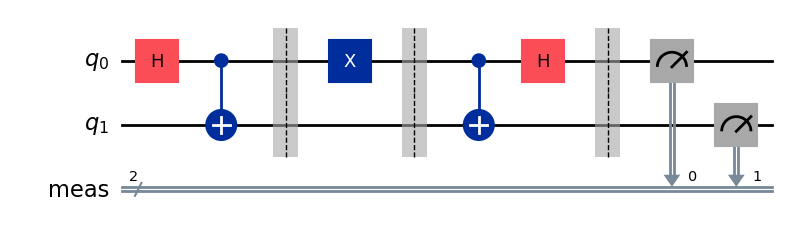

In [2]:
# example for cd = 10
c,d = ("1","0")

protocol = QuantumCircuit(2)
# Prepare ebit used for superdense coding
protocol.h(0)
protocol.cx(0,1)
protocol.barrier()

# Alice's operations
if d == "1":
    protocol.z(0)
if c == "1":
    protocol.x(0)
protocol.barrier()

# Bob's actions
protocol.cx(0, 1)
protocol.h(0)
protocol.measure_all()

display(protocol.draw("mpl"))

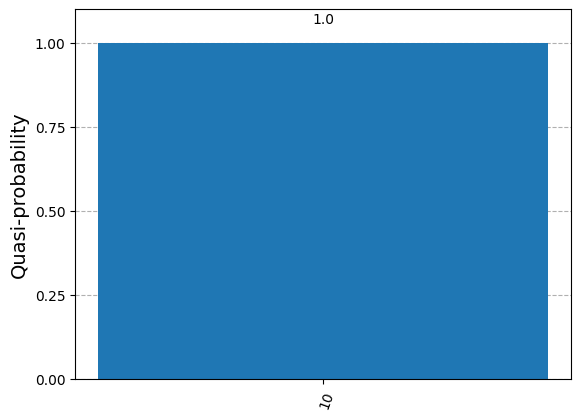

statistics =  {'10': 1.0}
Measured 10 with frequency 1.0


In [3]:
result = Sampler().run(protocol).result()
statistics = result.quasi_dists[0].binary_probabilities()
display(plot_histogram(statistics))
print("statistics = ",statistics)
for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")



### On real device

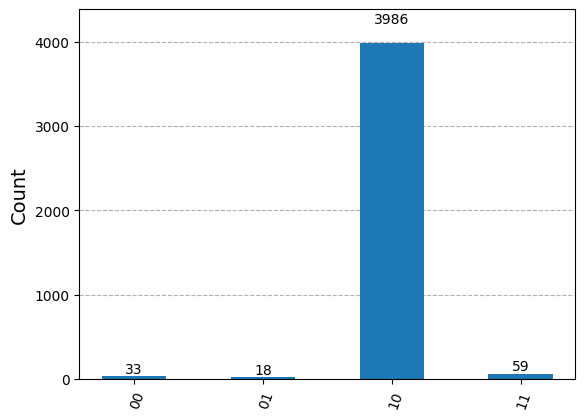

In [5]:
job = service.job('<job_id>')
job_result = job.result()

for idx, pub_result in enumerate(job_result):
    statistics = pub_result.data.meas.get_counts()
display(plot_histogram(statistics))

## Random test

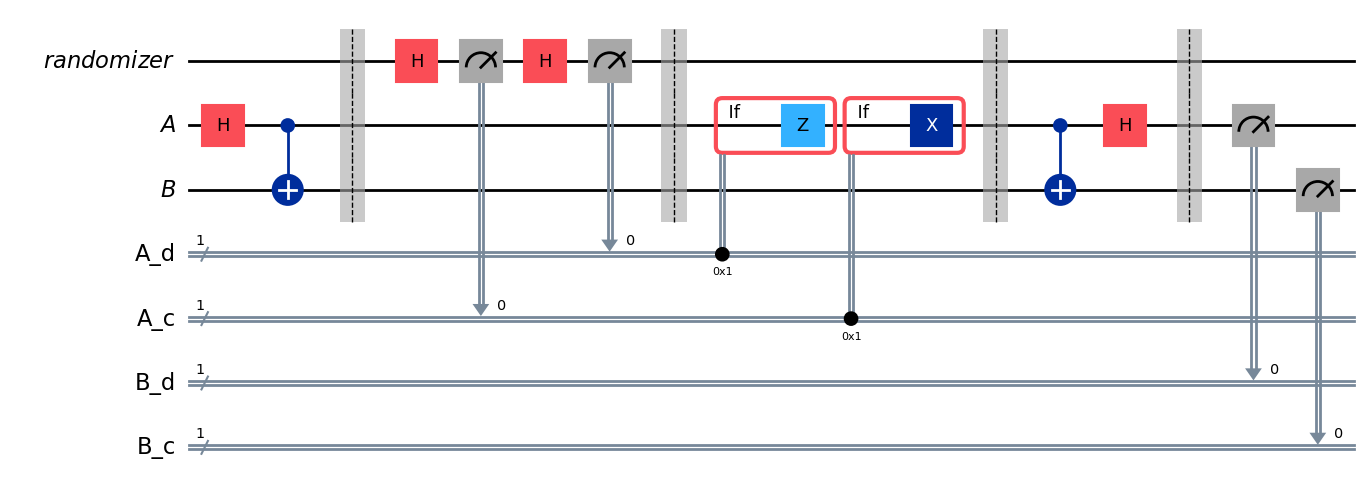

In [6]:
from qiskit_aer import AerSimulator

rbg = QuantumRegister(1, "randomizer")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

Alice_c = ClassicalRegister(1, "A_c")
Alice_d = ClassicalRegister(1, "A_d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_d, Alice_c)

# Initialize the ebit
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

# Use the 'randomizer' qubit twice to generate Alice's bits c and d.
test.h(rbg)
test.measure(rbg, Alice_c)
test.h(rbg)
test.measure(rbg, Alice_d)
test.barrier()

# Now the protocol runs, starting with Alice's actions, which depend
# on her bits.
with test.if_test((Alice_d, 1), label="Z"):
    test.z(ebit0)
with test.if_test((Alice_c, 1), label="X"):
    test.x(ebit0)
test.barrier()

# Bob's actions
test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()

Bob_c = ClassicalRegister(1, "B_c")
Bob_d = ClassicalRegister(1, "B_d")
test.add_register(Bob_d)
test.add_register(Bob_c)
test.measure(ebit0, Bob_d)
test.measure(ebit1, Bob_c)

display(test.draw("mpl"))

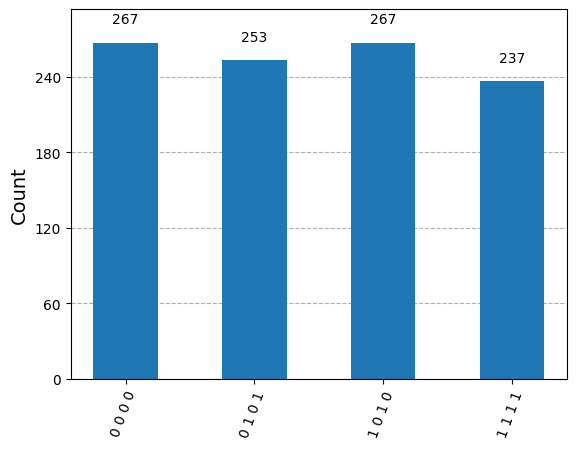

In [7]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))